# Week 9 workshop · What does entropy retain?

<span class="workshop-download-enabled" aria-hidden="true"></span>


# Context


**Canonical object:** a probability distribution summarised by Shannon entropy.  
**Modelling practice:** representation determines what a summary retains.  
**New toolkit:** empirical distributions, finite-sample sensitivity and reporting a measure with its construction choices.


# Specify the measurement

**Canonical object:** a probability distribution summarised by Shannon entropy,

$$
H(X)=-\sum_x p(x)\log_2 p(x).
$$

State the observed variable, outcome representation, sampling rule, sample size, logarithm base and sensitivity check. This week has no simulated world, boundary, interaction network or numerical time step.

## Pseudocode · a measurement pipeline

```text
INPUT observations
DEFINE the outcomes: symbols, bins, blocks or windows
COUNT occurrences and record the sample size
NORMALISE counts to probabilities
CHECK that probabilities sum to one
COMPUTE H = -SUM p(x) * log2(p(x))
REPEAT for defensible representations or resampled data
REPORT H together with every construction choice and one limitation
```

This pipeline measures observations; it does not generate the system that produced them.


In [1]:
from collections import Counter
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

def shannon_entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    p = p[p > 0]
    p = p / p.sum()
    return -np.sum(p * np.log2(p))

assert np.isclose(shannon_entropy([1, 0]), 0)
assert np.isclose(shannon_entropy([0.5, 0.5]), 1)
assert np.isclose(shannon_entropy(np.ones(6)), np.log2(6))


# Implement and test

Use four distributions as calibration cases. Predict their ordering before running the cell. The assertions above check three results that are known in advance.


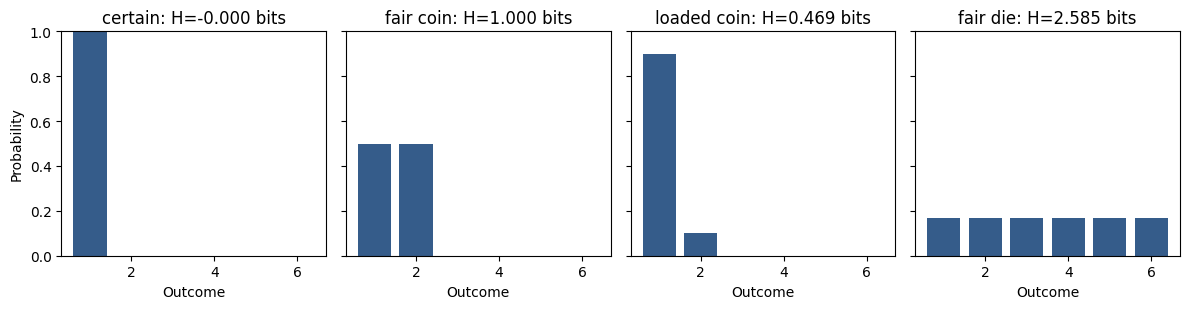

In [2]:
distributions = {
    "certain": np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
    "fair coin": np.array([0.5, 0.5, 0, 0, 0, 0]),
    "loaded coin": np.array([0.9, 0.1, 0, 0, 0, 0]),
    "fair die": np.ones(6) / 6,
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharey=True)
for ax, (name, p) in zip(axes, distributions.items()):
    ax.bar(np.arange(1, 7), p, color="#355c8a")
    ax.set(title=f"{name}: H={shannon_entropy(p):.3f} bits", xlabel="Outcome", ylim=(0, 1))
axes[0].set_ylabel("Probability")
plt.tight_layout()
plt.show()


# Analyse

The supplied texts provide a common dataset. The analysis progresses from single-letter frequencies to blocks and then checks whether the estimate is stable at smaller sample sizes.


## Define the observed sequence

The bundled files are public-domain texts from Project Gutenberg: [*Alice's Adventures in Wonderland*, eBook 11](https://www.gutenberg.org/ebooks/11) and [*Pride and Prejudice*, eBook 1342](https://www.gutenberg.org/ebooks/1342). The baseline keeps letters only and ignores case. These are representational choices rather than neutral preprocessing.


In [3]:
def data_path(filename):
    candidates = [Path("notebooks/week09/data") / filename, Path("data") / filename]
    return next(path for path in candidates if path.exists())

def letters_only(text):
    return re.sub("[^a-z]", "", text.lower())

texts = {
    "Alice": letters_only(data_path("alice_in_wonderland.txt").read_text(encoding="utf-8")),
    "Pride and Prejudice": letters_only(data_path("pride_and_prejudice.txt").read_text(encoding="utf-8")),
}

def symbol_probabilities(sequence):
    counts = Counter(sequence)
    symbols = sorted(counts)
    p = np.array([counts[s] for s in symbols], dtype=float)
    return symbols, p / p.sum()

for name, sequence in texts.items():
    _, p = symbol_probabilities(sequence)
    print(f"{name:20s}: {len(sequence):,} letters, H1={shannon_entropy(p):.3f} bits/letter")


Alice               : 123,393 letters, H1=4.172 bits/letter
Pride and Prejudice : 579,288 letters, H1=4.183 bits/letter


## Inspect the empirical distributions

Plot the frequencies before compressing each distribution to one entropy value. Check whether similar entropy values conceal visibly different distributions.


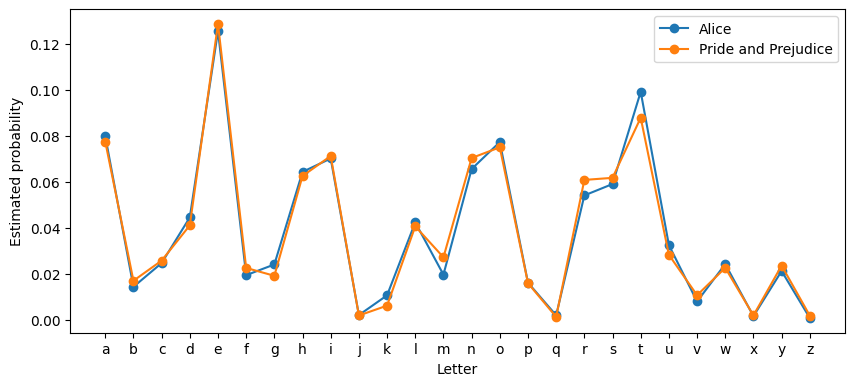

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2))
for name, sequence in texts.items():
    symbols, p = symbol_probabilities(sequence)
    ax.plot(symbols, p, marker="o", lw=1.5, label=name)
ax.set(xlabel="Letter", ylabel="Estimated probability")
ax.legend()
plt.show()


## Test what the representation discards

Shuffle every letter in *Alice*. The single-letter distribution, and therefore its single-letter entropy, is unchanged even though the text has lost its words, syntax and story. The formula has answered the question it was given; the representation excluded order.


In [5]:
rng = np.random.default_rng(3024)
alice = texts["Alice"]
shuffled = "".join(rng.permutation(list(alice)))

for name, sequence in [("original", alice), ("shuffled", shuffled)]:
    _, p = symbol_probabilities(sequence)
    print(name, shannon_entropy(p))


original 4.172408680332371
shuffled 4.172408680332371


## Retain short-range order

Treat overlapping groups of $m$ letters as outcomes. Block entropy retains some local ordering, but the number of possible blocks grows rapidly. Compare the original and shuffled text, then identify where finite data begin to limit the comparison.


In [6]:
def block_entropy(sequence, block_length):
    blocks = [sequence[i:i + block_length] for i in range(len(sequence) - block_length + 1)]
    _, p = symbol_probabilities(blocks)
    return shannon_entropy(p)

for m in range(1, 5):
    original_rate = block_entropy(alice, m) / m
    shuffled_rate = block_entropy(shuffled, m) / m
    print(f"m={m}: original {original_rate:.3f}, shuffled {shuffled_rate:.3f} bits/letter")


m=1: original 4.172, shuffled 4.172 bits/letter
m=2: original 3.869, shuffled 4.171 bits/letter
m=3: original 3.566, shuffled 4.143 bits/letter


m=4: original 3.221, shuffled 3.914 bits/letter


## Check finite-sample sensitivity

An entropy estimate is also a statistic calculated from a finite sample. The cell repeatedly samples passages of different lengths. Interpret both the average estimate and its spread; then decide whether the shortest sample would support the same claim as the full text.


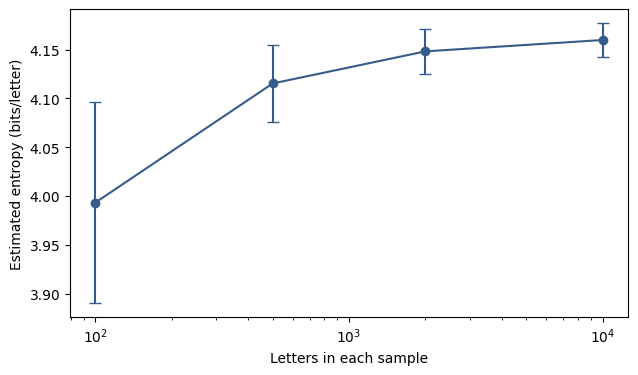

In [7]:
rng = np.random.default_rng(3024)
sample_sizes = [100, 500, 2_000, 10_000]
repeats = 30
estimates = {}

for n in sample_sizes:
    values = []
    for _ in range(repeats):
        start = rng.integers(0, len(alice) - n + 1)
        sample = alice[start:start + n]
        _, p = symbol_probabilities(sample)
        values.append(shannon_entropy(p))
    estimates[n] = np.asarray(values)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
means = [estimates[n].mean() for n in sample_sizes]
sds = [estimates[n].std(ddof=1) for n in sample_sizes]
ax.errorbar(sample_sizes, means, yerr=sds, marker="o", capsize=4, color="#355c8a")
ax.set(xscale="log", xlabel="Letters in each sample", ylabel="Estimated entropy (bits/letter)")
plt.show()


# Extend

## Design one measurement

Use another supplied text or suitable project data. Record these decisions before calculating anything:

1. What is the observed variable?
2. What counts as one outcome?
3. What sample or window is used?
4. Why is entropy, rather than another measure, relevant to the question?
5. Which alternative representation or resampling check will test sensitivity?
6. What will the final number necessarily discard?

Change one choice, compare the result and report a claim that does not exceed the measurement.


# Exit

Record the measure, its units, sample size and representation in one reproducible sentence. Add one result, one sensitivity check and one limitation. Bring the same measurement brief to your project.
